# Analyse ASR predictions

Score Whisper base / Whisper large-v3-turbo / Parakeet predictions against ground-truth transcripts and keywords, write long-format
`eval/results/asr_results.csv`, then visualise.

## 0. Setup


In [15]:
# %pip install -q pandas matplotlib jiwer whisper-normalizer rapidfuzz

In [16]:
from __future__ import annotations

import os

# Quieten macOS MallocStackLogging spam from child processes
os.environ["MallocStackLogging"] = "0"
os.environ.pop("MallocStackLoggingNoCompact", None)

import json
import re
import subprocess
from pathlib import Path

import jiwer
import matplotlib.pyplot as plt
import pandas as pd
from rapidfuzz.fuzz import partial_ratio
from whisper_normalizer.english import EnglishTextNormalizer

# Resolve repo root whether the kernel cwd is repo root or eval/analysis/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "analysis":
    # Notebook opened from eval/analysis/
    REPO_ROOT = REPO_ROOT.parents[1]
elif (REPO_ROOT / "eval").is_dir():
    # Already at repo root
    pass
else:
    # Walk up until we find eval/predictions/
    for p in [REPO_ROOT, *REPO_ROOT.parents]:
        if (p / "eval" / "predictions").is_dir():
            REPO_ROOT = p
            break

# Define paths
GT_PATH = REPO_ROOT / "eval" / "datasets" / "ground_truths" / "asr.jsonl"
PRED_DIR = REPO_ROOT / "eval" / "predictions" / "asr"
RESULTS_DIR = REPO_ROOT / "eval" / "results"
RESULTS_CSV = RESULTS_DIR / "asr_results.csv"

MODELS = ["whisper_base", "whisper_large_v3_turbo", "parakeet"]

print("REPO_ROOT:", REPO_ROOT)
print("GT:", GT_PATH.exists(), GT_PATH)
print("PRED_DIR:", PRED_DIR)


REPO_ROOT: /Users/desmond/Documents/University/Y3/FP/imet
GT: True /Users/desmond/Documents/University/Y3/FP/imet/eval/datasets/ground_truths/asr.jsonl
PRED_DIR: /Users/desmond/Documents/University/Y3/FP/imet/eval/predictions


## 1. Load

Read the prediction JSONLs, join ground truth on `id`, dump into one DataFrame.


In [17]:
def load_jsonl(path: Path) -> list[dict]:
    """
    Load rows from a JSONL file then convert into a list of dictionaries.
    """
    rows: list[dict] = []

    # Read file line by line
    for line in path.read_text(encoding="utf-8").splitlines():
        # Skip empty lines
        if not line.strip():
            continue
        # Parse JSON and add to list
        rows.append(json.loads(line))

    return rows


# Step 1: Load ground truth and index by id for joining
gt_rows = load_jsonl(GT_PATH)
gt_by_id = {
    int(r["id"]): {
        "transcript": r.get("transcript") or "",
        "keywords": r.get("keywords") or [],
        "condition": r.get("condition"),
        "speaker": r.get("speaker"),
    }
    for r in gt_rows
}

# Step 2: Load each model's predictions and join GT on id
pred_rows: list[dict] = []
for model in MODELS:
    pred_path = PRED_DIR / f"{model}.jsonl"
    # Skip models that have not been run yet
    if not pred_path.is_file():
        print(f"missing: {pred_path}")
        continue

    for row in load_jsonl(pred_path):
        row_id = int(row["id"])
        gt = gt_by_id.get(row_id) or {}
        pred_rows.append({
            "model": row.get("model") or model,
            "id": row_id,
            "condition": row.get("condition"),
            "audio": row.get("audio"),
            "transcript": row.get("transcript") or "",
            "latency_ms": row.get("latency_ms"),
            "error": row.get("error"),
            "gt_transcript": gt.get("transcript") or "",
            "keywords": gt.get("keywords") or [],
        })

# Step 3: Dump into one DataFrame (up to 180 rows = 3 models x 60 clips)
pred_df = pd.DataFrame(pred_rows)
print(pred_df.shape)
pred_df.head()

(180, 9)


,model,id,condition,audio,transcript,latency_ms,error,gt_transcript,keywords
0,whisper_base,1,raw,eval/datasets/audio/raw/asr_001.webm,"Okay, so um, just met Sarah Chen at the roofto...",1392.64,None,"Okay so, um, just met Sarah Chen at the roofto...","[Sarah Chen, Beamlight Studio, Camden, rooftop..."
1,whisper_base,2,raw,eval/datasets/audio/raw/asr_002.webm,"Right, so this is a Dan Wei Jin. We were both ...",2239.87,None,"Right, so this is, uh, Tan Wei Jian. We were b...","[Tan Wei Jian, campus career fair, Halcyon Dat..."
2,whisper_base,3,raw,eval/datasets/audio/raw/asr_003.webm,"Okay, Shiyoban Keller, S-I-O-B-H-A, and she's ...",3777.51,None,"Okay, um, Siobhan Kelleher. S-I-O-B-H-A-N, she...","[Siobhan Kelleher, Cork, Aliyah, Rotterdam Mar..."
3,whisper_base,4,raw,eval/datasets/audio/raw/asr_004.webm,a quick one. No role I share. We set next to e...,1337.59,None,"Uh, quick one. Nurul Aisyah, we sat next to ea...","[Nurul Aisyah, Danish, webflow, UX talk, freel..."
4,whisper_base,5,raw,eval/datasets/audio/raw/asr_005.webm,"So, a man a guy called, as he said during 4 ca...",1914.78,None,"So, um, met a guy called Aleksandr Volkov, goe...","[Aleksandr Volkov, Sasha, Delft, Novosibirsk, ..."


## 2. Score each row

Normalise reference, hypothesis, and keywords then score:

- **WER**
- **Keyword recall**
- **Keyword similarity**
- **RTFX**


In [18]:
_base = EnglishTextNormalizer()
FUZZY_THRESHOLD = 85

# Observed mismatches
PRE_RULES = [
    # 4.30 / 4:30 becomes 4 30
    (r"\b(\d{1,2})[.:](\d{2})\b", r"\1 \2"),
    # back-end becomes back end
    (r"-", " "),
]


def normalise(text: str) -> str:
    """Flatten text so we score speech recognition, not formatting."""
    if not text:
        return ""
    # Apply pre-rules
    for pattern, replacement in PRE_RULES:
        text = re.sub(pattern, replacement, text)
    # Lowercase, strip punctuation/fillers, map spelled numbers into digits
    return _base(text)


def score_wer(reference: str, hypothesis: str) -> float:
    """Word error rate on normalised text."""
    ref = normalise(reference)
    hyp = normalise(hypothesis)
    # Empty ref: nothing to score against (1.0 if hyp still produced words)
    if not ref:
        return 0.0 if not hyp else 1.0
    return float(jiwer.wer(ref, hyp))


def keyword_recall(hypothesis: str, keywords: list[str]) -> tuple[float, list[str], list[str]]:
    """Binary substring hit on normalised strings."""
    if not keywords:
        return float("nan"), [], []
    hyp = normalise(hypothesis)
    # Hit if the normalised keyword appears as a substring in the hyp
    hits = [k for k in keywords if normalise(k) in hyp]
    misses = [k for k in keywords if k not in hits]
    return len(hits) / len(keywords), hits, misses


def keyword_similarity_hits(hypothesis: str, keywords: list[str], threshold: int = FUZZY_THRESHOLD) -> list[int]:
    """
    Count a hit if the name is close enough (by threshold).
    e.g. "Markus Bell" still counts as a hit for "Marcus Bell"
    """
    hyp = normalise(hypothesis)
    out: list[int] = []
    for k in keywords:
        kn = normalise(k)
        if not kn:
            out.append(0)
            continue
        out.append(int(partial_ratio(kn, hyp) >= threshold))
    return out


def audio_duration_sec(path: Path) -> float | None:
    """Get the duration of an audio file in seconds."""
    # Check file exists
    if not path.is_file():
        return None
    try:
        # Get duration with ffprobe
        env = os.environ.copy()
        env["MallocStackLogging"] = "0"
        env.pop("MallocStackLoggingNoCompact", None)
        proc = subprocess.run(
            [
                "ffprobe",
                "-v",
                "error",
                "-show_entries",
                "format=duration",
                "-of",
                "default=noprint_wrappers=1:nokey=1",
                str(path),
            ],
            check=True,
            capture_output=True,
            text=True,
            env=env,
        )
        return float(proc.stdout.strip())
    except (subprocess.CalledProcessError, ValueError, FileNotFoundError):
        return None


def rtfx(duration_sec: float | None, latency_ms: float | None) -> float | None:
    """
    Real-time factor reciprocal
    To measure how many times faster than real time the model runs
    e.g. 20 means a 10s clip finished in ~0.5s
    """
    if duration_sec is None or latency_ms is None or latency_ms <= 0:
        return None
    return duration_sec / (latency_ms / 1000.0)


In [19]:
# Remember duration per audio path so we only ffprobe once
durations: dict[str, float | None] = {}


def get_duration(audio: str | None) -> float | None:
    """Get audio duration in seconds."""
    if not audio:
        return None
    if audio not in durations:
        # Get duration from ffprobe
        durations[audio] = audio_duration_sec(REPO_ROOT / audio)
    return durations[audio]

scored_rows: list[dict] = []
kw_hit_rows: list[dict] = []

# Score every prediction against its ground-truth transcript and keywords
for row in pred_df.itertuples(index=False):
    # Drop empty keyword strings
    keywords = [k for k in (row.keywords or []) if (k or "").strip()]

    # Keyword statistics
    recall, hits, misses = keyword_recall(row.transcript, keywords)
    # Similarity based keyword hits
    fuzzy_flags = keyword_similarity_hits(
        row.transcript, keywords, threshold=FUZZY_THRESHOLD
    )
    # Word error rate vs reference transcript
    wer = score_wer(row.gt_transcript, row.transcript)
    # Get audio duration
    duration_sec = get_duration(row.audio)
    # Get latency
    latency = row.latency_ms

    # Append row to list
    scored_rows.append({
        "id": row.id,
        "model": row.model,
        "condition": row.condition,
        "wer": wer,
        "keyword_recall": recall,
        "hits": hits,
        "misses": misses,
        "keyword_similarity": (
            (sum(fuzzy_flags) / len(fuzzy_flags)) if fuzzy_flags else float("nan")
        ),
        "latency_ms": latency,
        "duration_sec": duration_sec,
        "rtfx": rtfx(duration_sec, latency),
        "error": row.error,
        "n_keywords": len(keywords),
        "n_fuzzy_hits": int(sum(fuzzy_flags)) if fuzzy_flags else 0,
        "n_exact_hits": len(hits),
    })

    # Keep a flat keyword table for pooled recall later
    for k, fuzzy_hit in zip(keywords, fuzzy_flags):
        kw_hit_rows.append({
            "model": row.model,
            "id": row.id,
            "condition": row.condition,
            "keyword": k,
            "exact_hit": int(k in hits),
            "fuzzy_hit": int(fuzzy_hit),
        })

# Convert lists into DataFrames
scored_df = pd.DataFrame(scored_rows)
kw_hits_df = pd.DataFrame(kw_hit_rows)

display(scored_df.head(5))
display(kw_hits_df.head(5))

,id,model,condition,wer,keyword_recall,hits,misses,keyword_similarity,latency_ms,duration_sec,rtfx,error,n_keywords,n_fuzzy_hits,n_exact_hits
0,1,whisper_base,raw,0.113636,0.571429,"[Sarah Chen, Beamlight Studio, Camden, rooftop...","[leads growth, bouldering, beginner session]",0.571429,1392.64,25.461,18.282543,None,7,4,4
1,2,whisper_base,raw,0.243243,0.555556,"[campus career fair, Bali, coffee queue, backe...","[Tan Wei Jian, Halcyon Data, freediving, badmi...",0.666667,2239.87,42.961,19.180131,None,9,6,5
2,3,whisper_base,raw,0.205882,0.500000,"[Rotterdam Marathon, physiotherapist, housewar...","[Siobhan Kelleher, Cork, Aliyah, camogie, hurl...",0.600000,3777.51,77.081,20.405240,None,10,6,5
3,4,whisper_base,raw,0.288889,0.571429,"[Danish, UX talk, product design, follow up]","[Nurul Aisyah, webflow, freelance]",0.714286,1337.59,30.681,22.937522,None,7,5,4
4,5,whisper_base,raw,0.333333,0.444444,"[Sasha, Delft, computational biology, protein ...","[Aleksandr Volkov, Novosibirsk, Kreuzberg, che...",0.444444,1914.78,48.301,25.225352,None,9,4,4


,model,id,condition,keyword,exact_hit,fuzzy_hit
0,whisper_base,1,raw,Sarah Chen,1,1
1,whisper_base,1,raw,Beamlight Studio,1,1
2,whisper_base,1,raw,Camden,1,1
3,whisper_base,1,raw,rooftop mixer,1,1
4,whisper_base,1,raw,leads growth,0,0


## 3. Aggregate

Long-format metrics per `(model, condition)`:

| metric | how |
|---|---|
| `wer` | mean per-clip WER |
| `keyword_recall` | pooled exact keyword hits / total keywords |
| `keyword_similarity` | pooled fuzzy (≥85) hits / total keywords |
| `latency_ms_mean` | mean model latency |
| `rtfx_mean` | mean RTFX |


In [ ]:
metric_rows: list[dict] = []

# One block of metrics per model x condition
for (model, condition), g in scored_df.groupby(["model", "condition"], sort=True):
    # Keyword hits for this model/condition (for pooled recall)
    kw = kw_hits_df[(kw_hits_df["model"] == model) & (kw_hits_df["condition"] == condition)]
    n_kw = len(kw)

    def add(metric: str, value) -> None:
        # Long-format row: model, condition, metric name, value
        metric_rows.append({
            "model": model,
            "condition": condition,
            "metric": metric,
            "value": float(value) if pd.notna(value) else float("nan"),
        })

    # Clip-level means
    add("wer", g["wer"].mean())
    # Keyword-level means (all keywords pooled, not averaged per clip)
    add("keyword_recall", kw["exact_hit"].mean() if n_kw else float("nan"))
    add("keyword_similarity", kw["fuzzy_hit"].mean() if n_kw else float("nan"))
    # Speed
    add("latency_ms_mean", g["latency_ms"].mean())
    add("rtfx_mean", g["rtfx"].mean())

results = pd.DataFrame(metric_rows)
results = results.sort_values(["model", "condition", "metric"]).reset_index(drop=True)

# Wide table (one column per metric) for plots
agg = (
    results.pivot_table(index=["model", "condition"], columns="metric", values="value")
    .reset_index()
)
agg


metric,model,condition,keyword_recall,keyword_similarity,latency_ms_mean,rtfx_mean,wer
0,parakeet,babble_snr10,0.704545,0.778409,2814.5460,20.754770,0.094539
1,parakeet,babble_snr20,0.778409,0.846591,2493.1855,21.510797,0.067951
2,parakeet,raw,0.806818,0.875000,2216.5355,23.725622,0.057321
3,whisper_base,babble_snr10,0.488636,0.562500,2802.8855,17.933101,0.272100
4,whisper_base,babble_snr20,0.636364,0.704545,4787.7125,11.363428,0.178582
5,whisper_base,raw,0.653409,0.732955,2219.9430,21.085700,0.179137
6,whisper_large_v3_turbo,babble_snr10,0.721591,0.801136,25220.3320,2.042119,0.142388
7,whisper_large_v3_turbo,babble_snr20,0.795455,0.869318,25297.7120,2.036954,0.095585
8,whisper_large_v3_turbo,raw,0.801136,0.886364,24485.8265,2.230459,0.130310


## 4. Save

Overwrite `eval/results/asr_results.csv` (long format).


In [21]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Long-format aggregate metrics
results.to_csv(RESULTS_CSV, index=False)
print(f"Wrote {len(results)} rows to {RESULTS_CSV.relative_to(REPO_ROOT)}")
results.head(10)


Wrote 45 rows to eval/results/asr_results.csv


,model,condition,metric,value
0,parakeet,babble_snr10,keyword_recall,0.704545
1,parakeet,babble_snr10,keyword_similarity,0.778409
2,parakeet,babble_snr10,latency_ms_mean,2814.546000
3,parakeet,babble_snr10,rtfx_mean,20.754770
4,parakeet,babble_snr10,wer,0.094539
5,parakeet,babble_snr20,keyword_recall,0.778409
6,parakeet,babble_snr20,keyword_similarity,0.846591
7,parakeet,babble_snr20,latency_ms_mean,2493.185500
8,parakeet,babble_snr20,rtfx_mean,21.510797
9,parakeet,babble_snr20,wer,0.067951


## 5. Visualisation

1. Accuracy vs latency scatter
2. Degradation curve (WER by condition)
3. Keyword recall by model and condition
4. Full diagnostic heatmap


In [22]:
# Chart constants
MODEL_ORDER = ["whisper_base", "whisper_large_v3_turbo", "parakeet"]
# condition severity order
CONDITION_ORDER = ["raw", "babble_snr20", "babble_snr10"]

MARKERS = {
    "raw": "o",
    "babble_snr20": "^",
    "babble_snr10": "s",
}

# Only show models that have data
present_models = [m for m in MODEL_ORDER if m in set(agg["model"])]

# Copy and sort by model and condition
agg_plot = agg.copy()
agg_plot["condition"] = pd.Categorical(
    agg_plot["condition"], categories=CONDITION_ORDER, ordered=True
)
agg_plot = agg_plot.sort_values(["model", "condition"]).reset_index(drop=True)
agg_plot

metric,model,condition,keyword_recall,keyword_similarity,latency_ms_mean,rtfx_mean,wer
0,parakeet,raw,0.806818,0.875000,2216.5355,23.725622,0.057321
1,parakeet,babble_snr20,0.778409,0.846591,2493.1855,21.510797,0.067951
2,parakeet,babble_snr10,0.704545,0.778409,2814.5460,20.754770,0.094539
3,whisper_base,raw,0.653409,0.732955,2219.9430,21.085700,0.179137
4,whisper_base,babble_snr20,0.636364,0.704545,4787.7125,11.363428,0.178582
5,whisper_base,babble_snr10,0.488636,0.562500,2802.8855,17.933101,0.272100
6,whisper_large_v3_turbo,raw,0.801136,0.886364,24485.8265,2.230459,0.130310
7,whisper_large_v3_turbo,babble_snr20,0.795455,0.869318,25297.7120,2.036954,0.095585
8,whisper_large_v3_turbo,babble_snr10,0.721591,0.801136,25220.3320,2.042119,0.142388


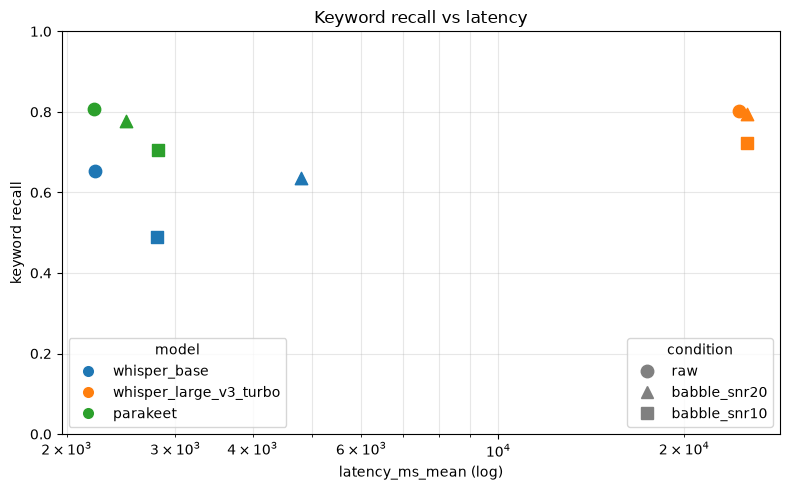

In [ ]:
# 1. Accuracy vs latency scatter
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(present_models):
    m = agg_plot[agg_plot["model"] == model]
    for _, row in m.iterrows():
        ax.scatter(
            row["latency_ms_mean"],
            row["keyword_recall"],
            color=f"C{i}",
            marker=MARKERS[row["condition"]],
            s=80,
            zorder=3,
            label="_nolegend_",
        )

# Legends: colour = model, shape = condition
model_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=f"C{i}", markersize=9, label=m)
    for i, m in enumerate(present_models)
]
cond_handles = [
    Line2D([0], [0], marker=MARKERS[c], color="gray", linestyle="None", markersize=9, label=c)
    for c in CONDITION_ORDER
]
leg1 = ax.legend(handles=model_handles, title="model", loc="lower left")
ax.add_artist(leg1)
ax.legend(handles=cond_handles, title="condition", loc="lower right")

ax.set_xscale("log")
ax.set_xlabel("latency_ms_mean (log)")
ax.set_ylabel("keyword recall")
ax.set_ylim(0, 1)
ax.set_title("Keyword recall vs latency")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

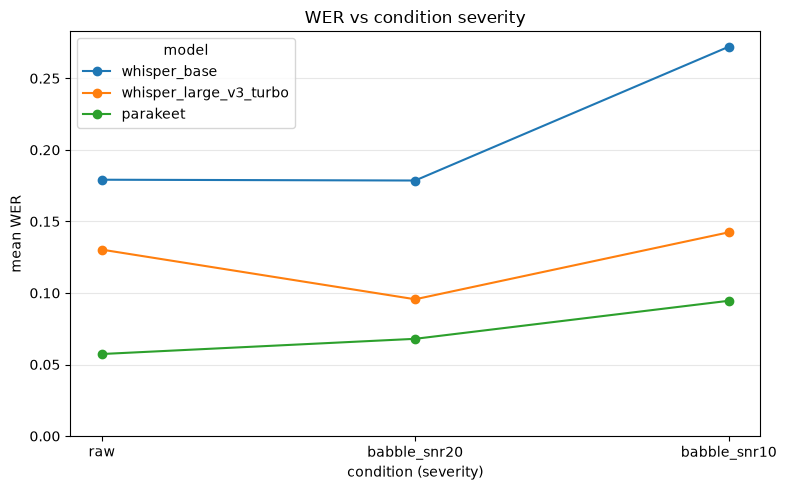

In [ ]:
# 2. Degradation curve (WER by condition)
fig, ax = plt.subplots(figsize=(8, 5))

for model in present_models:
    m = agg_plot[agg_plot["model"] == model].sort_values("condition")
    ax.plot(
        m["condition"].astype(str),
        m["wer"],
        marker="o",
        label=model,
    )

ax.set_xlabel("condition (severity)")
ax.set_ylabel("mean WER")
ax.set_ylim(bottom=0)
ax.set_title("WER vs condition severity")
ax.legend(title="model")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

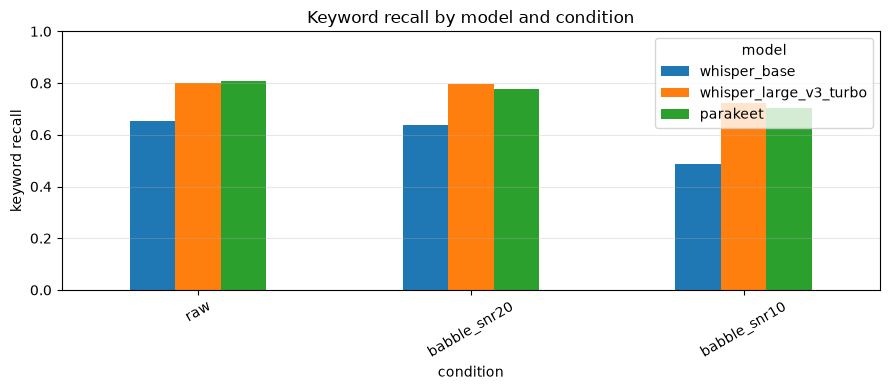

In [ ]:
# 3. Keyword recall by model and condition
pivot_recall = agg_plot.pivot(index="condition", columns="model", values="keyword_recall")
pivot_recall = pivot_recall.reindex(index=CONDITION_ORDER, columns=present_models)

ax = pivot_recall.plot(kind="bar", figsize=(9, 4), rot=30)
ax.set_ylabel("keyword recall")
ax.set_xlabel("condition")
ax.set_title("Keyword recall by model and condition")
ax.set_ylim(0, 1)
ax.legend(title="model")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

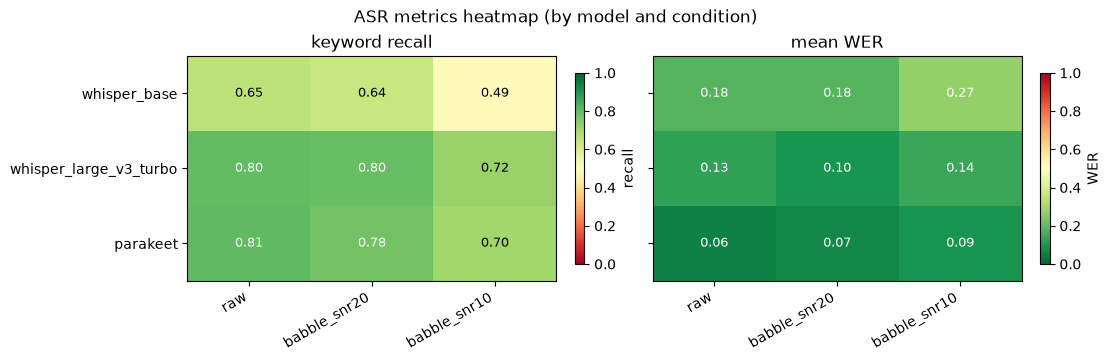

In [ ]:
# 4. Full diagnostic heatmap (keyword recall + WER)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True, layout="constrained")

# Keyword recall heatmap
recall_pivot = agg_plot.pivot(index="model", columns="condition", values="keyword_recall")
recall_pivot = recall_pivot.reindex(index=present_models, columns=CONDITION_ORDER)

ax = axes[0]
cmap_recall = plt.cm.RdYlGn
norm_recall = plt.Normalize(vmin=0, vmax=1)
im0 = ax.imshow(recall_pivot.values, aspect="auto", cmap=cmap_recall, norm=norm_recall)
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels(CONDITION_ORDER, rotation=30, ha="right")
ax.set_yticks(range(len(present_models)))
ax.set_yticklabels(present_models)
ax.set_title("keyword recall")
for i in range(recall_pivot.shape[0]):
    for j in range(recall_pivot.shape[1]):
        val = recall_pivot.values[i, j]
        if pd.isna(val):
            continue
        text_color = "black" if 0.3 < val < 0.75 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=9)
fig.colorbar(im0, ax=ax, shrink=0.85, label="recall")

# WER heatmap
wer_pivot = agg_plot.pivot(index="model", columns="condition", values="wer")
wer_pivot = wer_pivot.reindex(index=present_models, columns=CONDITION_ORDER)

ax = axes[1]
cmap_wer = plt.cm.RdYlGn_r
wer_max = float(wer_pivot.max().max()) if wer_pivot.size and not pd.isna(wer_pivot.max().max()) else 1.0
norm_wer = plt.Normalize(vmin=0, vmax=max(1.0, wer_max))
im1 = ax.imshow(wer_pivot.values, aspect="auto", cmap=cmap_wer, norm=norm_wer)
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels(CONDITION_ORDER, rotation=30, ha="right")
ax.set_yticks(range(len(present_models)))
ax.set_yticklabels(present_models)
ax.set_title("mean WER")
for i in range(wer_pivot.shape[0]):
    for j in range(wer_pivot.shape[1]):
        val = wer_pivot.values[i, j]
        if pd.isna(val):
            continue
        mid = norm_wer.vmax / 2
        text_color = "black" if abs(val - mid) < mid * 0.4 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=9)
fig.colorbar(im1, ax=ax, shrink=0.85, label="WER")

fig.suptitle("ASR metrics heatmap (by model and condition)")
plt.show()